In [1]:
import pandas as pd     # data manipulation
import numpy as np      # numerical operations
import matplotlib.pyplot as plt     # data visualization
import seaborn as sns           # statistical data visualization
from nltk.sentiment.vader import SentimentIntensityAnalyzer     # sentiment analysis
import nltk     # natural language processing
import emoji    # emoji handling

In [2]:
# download the VADER lexicon for sentiment analysis

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Vaishnavi
[nltk_data]     Giri\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
# load the data

df = pd.read_csv('../data/enriched_data.csv')

In [4]:
print(f"Dataset loaded with {len(df)} rows.")
df.head()

Dataset loaded with 1429 rows.


,review_text,rating,word_count,is_fake,is_duplicate,emojis,sentiment
0,Nice product for family of 4,4.0,6,0,1,NaN,Positive
1,Not Good product,1.0,3,0,1,NaN,Negative
2,Works best with PPPoE type cable internet RJ45,5.0,8,0,1,NaN,Positive
3,nice,5.0,1,1,1,NaN,Positive
4,Sharp upper edges.,1.0,3,0,1,NaN,Negative


In [5]:
# initialize the SentimentIntensityAnalyzer for sentiment analysis tasks
sid = SentimentIntensityAnalyzer()

In [6]:
# example of SentimentIntensityAnalyzer for a sample text to demonstrate how it works, where it calculates the polarity scores (positive, negative, neutral, and compound) for the given text input
sample_text = "Amazing product! 😍 love it."
print(f"Sample Score: {sid.polarity_scores(sample_text)}")

Sample Score: {'neg': 0.0, 'neu': 0.194, 'pos': 0.806, 'compound': 0.8516}


In [7]:
# create a new column 'scores' by applying the VADER sentiment analysis
# to the 'review_text' column because we want to analyze the sentiment of each review

df['scores'] = df['review_text'].apply(lambda review: sid.polarity_scores(str(review)))

In [8]:
# create a new column 'compound' added by extracting the 'compound' score from the 'scores' dictionary

df['compound'] = df['scores'].apply(lambda score_dict: score_dict['compound'])

In [9]:
# function to determine the final sentiment label based on both the rating 
# and the compound score, where it categorizes reviews as 'Positive', 'Negative', or 'Neutral' 
# based on the rating and the compound score thresholds
# compound score between -0.05 and 0.05 is considered neutral, 
# while scores above 0.05 are positive and below -0.05 are negative

def get_final_label(row):
    if row['rating'] >= 4:
        return 'Positive'
    
    elif row['rating'] <= 2:
        return 'Negative'
    
    else:
        if row['compound'] >= 0.05:
            return 'Positive'
        elif row['compound'] <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

In [10]:
# apply the function to each row of the DataFrame to create a new column 'sentiment'
df['sentiment'] = df.apply(get_final_label, axis=1)

In [11]:
# positive negative neutral count
print(df['sentiment'].value_counts())

sentiment
Positive    1040
Negative     332
Neutral       57
Name: count, dtype: int64


In [12]:
# Positive: 2, Neutral: 1, Negative: 0
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)

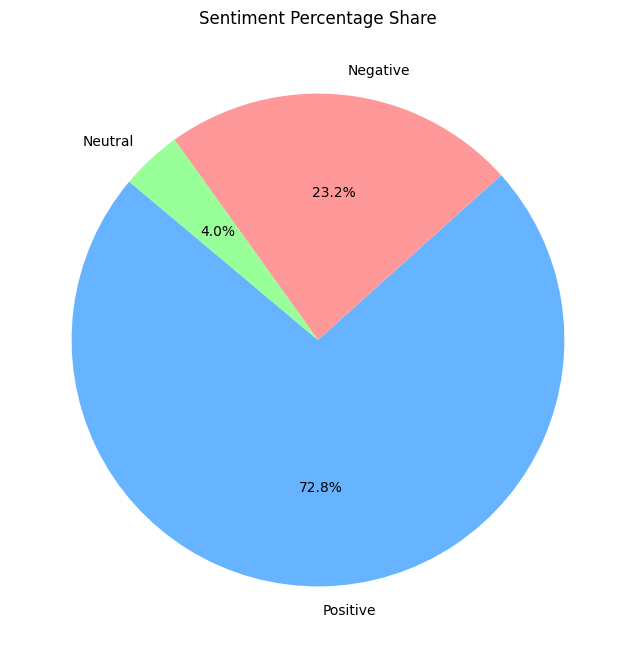

In [13]:
# visualize the distribution of sentiment labels using a pie chart, 
# where it shows the percentage share of each sentiment category (Positive, Negative, Neutral) 
# in the dataset with different colors for better visualization

plt.figure(figsize=(8, 8))
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'], startangle=140)
plt.title('Sentiment Percentage Share')
plt.ylabel('') 
plt.show()

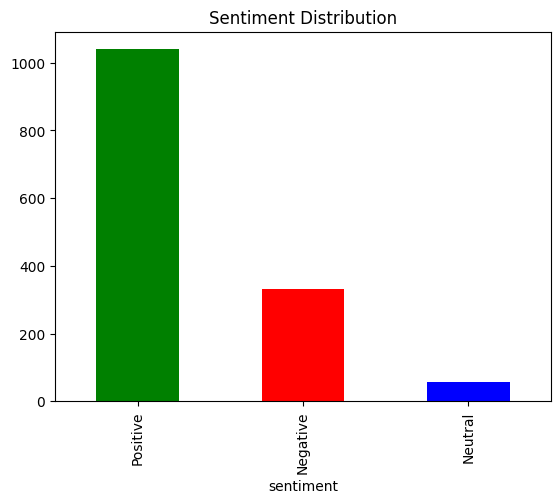

In [14]:
# bar plot showing the distribution of sentiments in the dataset
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution')
plt.show()

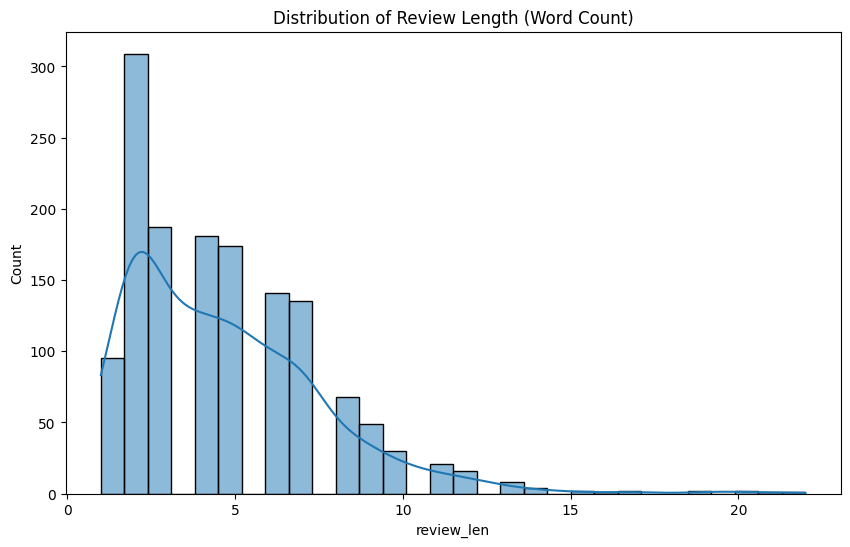

In [15]:
# visualize the distribution of review lengths (in terms of word count) using a histogram,
# where it calculates the length of each review by counting the number of words and
# then plots a histogram to show how review lengths are distributed across the 
# dataset, with a kernel density estimate (KDE) to visualize the density of review lengths

df['review_len'] = df['review_text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['review_len'], bins=30, kde=True)
plt.title('Distribution of Review Length (Word Count)')
plt.show()

In [16]:
# saving the final labeled DataFrame to a new CSV file for further analysis or modeling, with UTF-8 encoding to handle any special characters or emojis properly
df.to_csv('../data/final_labeled_data.csv', index=False, encoding='utf-8-sig')

In [17]:
print(df[['review_text','sentiment','label']].head(10))

                                      review_text sentiment  label
0                    Nice product for family of 4  Positive      2
1                                Not Good product  Negative      0
2  Works best with PPPoE type cable internet RJ45  Positive      2
3                                            nice  Positive      2
4                              Sharp upper edges.  Negative      0
5                               Excellent Machine  Positive      2
6                                  Very hard ball  Negative      0
7                                         Damaged  Negative      0
8                                  Superb product  Positive      2
9                             high class speakers  Positive      2
